# Problém učení s chybami (Learning With Errors - LWE) - Ukázková implementace

Tento notebook demonstruje problém **učení s chybami (Learning With Errors - LWE)**, který je základním problémem v kryptografii založené na mřížkách a postkvantové kryptografii.

## Přehled

Problém LWE, představený Odedem Regevem v roce 2005, je založen na obtížnosti řešení zašuměných lineárních rovnic. Dány jsou vzorky ve tvaru:

$$(\mathbf{a}, b = \langle \mathbf{a}, \mathbf{s} \rangle + e \mod q)$$

kde:
- $\mathbf{a} \in \mathbb{Z}_q^n$ je náhodný vektor
- $\mathbf{s} \in \mathbb{Z}_q^n$ je tajný vektor
- $e$ je malá chyba z distribuci šumu
- $q$ je modulus

Cílem je obnovit tajemství $\mathbf{s}$, což je výpočetně náročné, když je dimenze $n$ a modulus $q$ dostatečně velký.

## Import potřebných knihoven

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Nastavení náhodného seedu pro reprodukovatelnost
np.random.seed(42)

print("Knihovny úspěšně naimportovány!")

Knihovny úspěšně naimportovány!


## Implementace třídy ToyLWE

Třída `ToyLWE` implementuje zjednodušenou verzi šifrování založeného na LWE. Jedná se o "hračkovou" implementaci určenou pro ukázkové účely s malými parametry.

### Parametry:
- **n (dimenze)**: Dimenze tajného vektoru a každého řádku matice A
- **q (modulus)**: Všechny operace jsou prováděny modulo q
- **sigma (směrodatná odchylka chyby)**: Směrodatná odchylka Gaussovy distribuci chyb

In [12]:
class ToyLWE:
    """
    Toy implementace šifrování založeného na Learning With Errors (LWE).
    """
    
    def __init__(self, n, q, sigma):
        """
        Inicializace LWE kryptosystému se specifikovanými parametry.
        
        Parametry:
        -----------
        n : int - Dimenze tajného vektoru (bezpečnostní parametr)
        q : int - Modulus pro všechny aritmetické operace
        sigma : float - Směrodatná odchylka Gaussovy distribuci chyb
        """
        self.n = n          # Dimenze
        self.q = q          # Modulus
        self.sigma = sigma  # Parametr distribuci chyb
        
        # Tyto budou nastaveny během generování klíčů
        self.A = None       # Veřejná matice
        self.s = None       # Tajný klíč
        self.b = None       # Veřejný klíč (odvozený z A, s a chyby)
        
    def keygen(self):
        """
        Generování veřejného a soukromého klíče pro LWE kryptosystém.
        
        Proces generování klíčů:
        1. Vygenerovat náhodnou matici A o velikosti (n x n) s prvky v Z_q
        2. Vygenerovat tajný vektor s o velikosti n s prvky v Z_q
        3. Vygenerovat chybový vektor e z Gaussovy distribuce se směr. odchylkou sigma
        4. Vypočítat veřejný klíč: b = (A @ s + e) mod q
        
        Veřejný klíč je (A, b) a soukromý klíč je s.
        """
        # Krok 1: Vygenerovat náhodnou veřejnou matici A s prvky rovnoměrně v [0, q)
        self.A = np.random.randint(0, self.q, size=(self.n, self.n))
        
        # Krok 2: Vygenerovat náhodný tajný vektor s s prvky rovnoměrně v [0, q)
        self.s = np.random.randint(0, self.q, size=self.n)
        
        # Krok 3: Vygenerovat chybový vektor e z diskrétní Gaussovy distribuce
        # Vzorkujeme ze spojité Gaussovy distribuce a zaokrouhlíme na nejbližší celé číslo
        e = np.random.normal(0, self.sigma, size=self.n)
        e = np.round(e).astype(int)
        
        # Krok 4: Vypočítat veřejný klíč b = (A @ s + e) mod q
        # Toto jsou LWE vzorky: (A, b) kde b ≈ A @ s (s malým šumem e)
        self.b = (self.A @ self.s + e) % self.q
        
        return self.A, self.b, self.s
    
    def encrypt(self, message_bit):
        """
        Šifrování jednoho bitu (0 nebo 1) pomocí LWE veřejného klíče.
        
        Proces šifrování:
        1. Vzorkovat náhodný binární vektor r o velikosti n
        2. Vypočítat u = (r^T @ A) mod q (toto skrývá, které řádky A používáme)
        3. Vypočítat v = (r^T @ b) mod q
        4. Pokud message_bit = 1, přidat q//2 k v (toto vloží zprávu)
        
        Šifrový text je (u, v).
        
        Parametry:
        -----------
        message_bit : int
            Bit k zašifrování (0 nebo 1)
            
        Návratová hodnota:
        --------
        tuple : (u, v)
            Dvojice šifrového textu
        """
        if self.A is None or self.b is None:
            raise ValueError("Klíče musí být vygenerovány před šifrováním!")
        
        if message_bit not in [0, 1]:
            raise ValueError("Zpráva musí být jeden bit (0 nebo 1)")
        
        # Krok 1: Vzorkovat náhodný binární vektor r (vektor pro výběr podmnožiny)
        # Každý prvek je 0 nebo 1, určuje které LWE vzorky zkombinovat
        r = np.random.randint(0, 2, size=self.n)
        
        # Krok 2: Vypočítat u = (r^T @ A) mod q
        # Toto vytvoří čerstvý náhodný vektor (lineární kombinace řádků A)
        u = (r @ self.A) % self.q
        
        # Krok 3: Vypočítat v = (r^T @ b) mod q
        # Protože b ≈ A @ s, máme v ≈ r^T @ A @ s = u @ s
        v = (r @ self.b) % self.q
        
        # Krok 4: Zakódovat bit zprávy přidáním q//2, pokud je bit 1
        # Toto posune hodnotu do jiné "oblasti" modulo q
        if message_bit == 1:
            v = (v + self.q // 2) % self.q
        
        return u, v
    
    def decrypt(self, ciphertext):
        """
        Dešifrování šifrového textu pro obnovení původního bitu zprávy.
        
        Proces dešifrování:
        1. Analyzovat šifrový text jako (u, v)
        2. Vypočítat noisy_message = (v - u @ s) mod q
        3. Výsledek by měl být blízko 0 (pro bit 0) nebo q//2 (pro bit 1)
        4. Prahování na q//4: pokud noisy_message < q//4 nebo > 3q//4, vrátit 0; jinak vrátit 1
        
        Parametry:
        -----------
        ciphertext : tuple
            Dvojice šifrového textu (u, v)
            
        Návratová hodnota:
        --------
        int : Dešifrovaný bit (0 nebo 1)
        """
        if self.s is None:
            raise ValueError("Tajný klíč musí být dostupný pro dešifrování!")
        
        u, v = ciphertext
        
        # Krok 1: Vypočítat zašuměnou zprávu = (v - u @ s) mod q
        noisy_message = (v - u @ self.s) % self.q
        
        # Krok 2: Prahování pro obnovení bitu
        # Pokud je noisy_message blízko 0, bit byl 0
        # Pokud je noisy_message blízko q//2, bit byl 1
        # Používáme q//4 jako rozhodovací hranici
        if noisy_message < self.q // 4 or noisy_message > 3 * self.q // 4:
            return 0
        else:
            return 1

## Testování kryptosystému

Testování šifrování a dešifrování obou bitů (0 a 1).

In [13]:
# Inicializace LWE systému s hračkovými parametry
n = 10        # Dimenze (malá pro vzdělávací účely)
q = 257        # Modulus (prvočíslo)
sigma = 1.5   # Směrodatná odchylka chyby

# Vytvoření LWE instance
lwe = ToyLWE(n=n, q=q, sigma=sigma)

# Generování klíčů
A, b, s = lwe.keygen()

print(f"Parametry: n={n}, q={q}, sigma={sigma}")
print(f"Tajný klíč s: {s}")
print(f"Tvar veřejné matice A: {A.shape}")
print(f"Veřejný vektor b: {b}")
print("\nKlíče úspěšně vygenerovány!")

Parametry: n=10, q=257, sigma=1.5
Tajný klíč s: [236 142 170  28  35  12 159 186 242  85]
Tvar veřejné matice A: (10, 10)
Veřejný vektor b: [147   0   9  47 132  99 162 208  66   3]

Klíče úspěšně vygenerovány!


In [14]:
# Test šifrování a dešifrování pro bit 0
message_bit_0 = 0
ciphertext_0 = lwe.encrypt(message_bit_0)
decrypted_0 = lwe.decrypt(ciphertext_0)

print(f"Původní bit: {message_bit_0}")
print(f"Šifrový text: u={ciphertext_0[0]}, v={ciphertext_0[1]}")
print(f"Dešifrovaný bit: {decrypted_0}")
print(f"Úspěch: {message_bit_0 == decrypted_0}")

print("\n" + "="*50 + "\n")

# Test šifrování a dešifrování pro bit 1
message_bit_1 = 1
ciphertext_1 = lwe.encrypt(message_bit_1)
decrypted_1 = lwe.decrypt(ciphertext_1)

print(f"Původní bit: {message_bit_1}")
print(f"Šifrový text: u={ciphertext_1[0]}, v={ciphertext_1[1]}")
print(f"Dešifrovaný bit: {decrypted_1}")
print(f"Úspěch: {message_bit_1 == decrypted_1}")

Původní bit: 0
Šifrový text: u=[223 255 244 179  55  84  98 183 196 164], v=220
Dešifrovaný bit: 0
Úspěch: True


Původní bit: 1
Šifrový text: u=[146  42  24  12 142   1 159  91 251  99], v=168
Dešifrovaný bit: 1
Úspěch: True


## Vizualizace distribuce chyb

Nyní spustíme proces šifrování 1000krát a analyzujeme distribuci chyb. Tato vizualizace nám pomůže porozumět:

1. **Jak blízko se chyby dostanou k hranici selhání dešifrování**
2. **Bezpečnostní rezervě kryptosystému**
3. **Vztahu mezi distribucí chyb a správností dešifrování**

Histogram ukáže dva shluky:
- Jeden vycentrovaný blízko **0** (pro šifrování bitu 0)
- Jeden vycentrovaný blízko **q/2** (pro šifrování bitu 1)

**Hranice selhání** je na q/4 a 3q/4. Pokud chyby způsobí překročení těchto hranic zašuměnou zprávou, dešifrování selže.

In [15]:
def analyze_error_distribution(lwe, num_trials=1000):
    """
    Analýza distribuce chyb spouštěním vícenásobných šifrování.
    
    Tato funkce šifruje náhodné bity vícekrát a sbírá zašuměné
    hodnoty dešifrování pro vizualizaci, jak blízko se chyby dostanou
    k způsobení selhání dešifrování.
    
    Parametry:
    -----------
    lwe : ToyLWE
        Inicializovaná LWE instance s vygenerovanými klíči
    num_trials : int
        Počet šifrovacích pokusů ke spuštění
        
    Návratová hodnota:
    --------
    tuple : (errors_bit0, errors_bit1, failures)
        Seznamy zašuměných hodnot zpráv a počet selhání dešifrování
    """
    errors_bit0 = []  # Zašuměné zprávy při šifrování bitu 0
    errors_bit1 = []  # Zašuměné zprávy při šifrování bitu 1
    failures = 0      # Počet selhání dešifrování
    
    for _ in range(num_trials):
        # Náhodně vybrat, který bit šifrovat
        original_bit = np.random.randint(0, 2)
        
        # Šifrovat a dešifrovat
        ciphertext = lwe.encrypt(original_bit)
        u, v = ciphertext
        
        # Vypočítat zašuměnou zprávu (stejný výpočet jako v decrypt)
        noisy_message = (v - u @ lwe.s) % lwe.q
        
        # Uložit chybu na základě toho, který bit byl šifrován
        if original_bit == 0:
            errors_bit0.append(noisy_message)
        else:
            errors_bit1.append(noisy_message)
        
        # Zkontrolovat, zda by dešifrování bylo úspěšné
        decrypted_bit = lwe.decrypt(ciphertext)
        if decrypted_bit != original_bit:
            failures += 1
    
    return errors_bit0, errors_bit1, failures

# Spuštění analýzy
print("Spouštím 1000 šifrovacích pokusů...")
errors_0, errors_1, num_failures = analyze_error_distribution(lwe, num_trials=1000)

print(f"\nDokončeno 1000 pokusů")
print(f"Selhání dešifrování: {num_failures}")
print(f"Úspěšnost: {(1000 - num_failures) / 1000 * 100:.2f}%")

Spouštím 1000 šifrovacích pokusů...

Dokončeno 1000 pokusů
Selhání dešifrování: 0
Úspěšnost: 100.00%


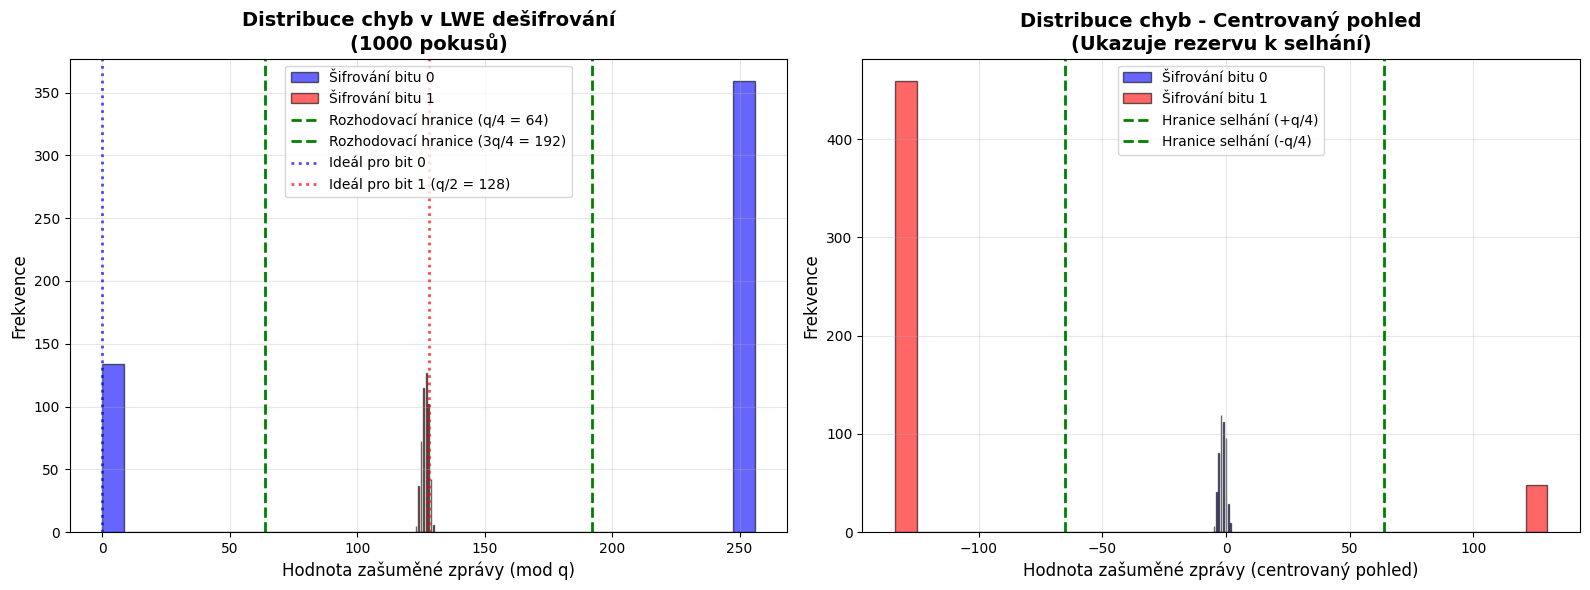


Statistická analýza:
Šifrování bitu 0:
  Průměrná chyba: 185.65
  Sm. odchylka: 113.21
  Min: 0, Max: 256
  Vzdálenost k hranici selhání (q/4 = 64): -192

Šifrování bitu 1:
  Průměrná chyba: 126.63
  Sm. odchylka: 1.46
  Min: 123, Max: 130
  Vzdálenost k hranici selhání (3q/4 = 192): -69

Bezpečnostní rezerva: Chyby zůstávají bezpečně v bezpečné zóně!


In [16]:
# Vytvoření vizualizace
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graf 1: Kombinovaný histogram zobrazující obě distribuce
ax1.hist(errors_0, bins=30, alpha=0.6, label='Šifrování bitu 0', color='blue', edgecolor='black')
ax1.hist(errors_1, bins=30, alpha=0.6, label='Šifrování bitu 1', color='red', edgecolor='black')

# Označení rozhodovacích hranic
ax1.axvline(x=lwe.q // 4, color='green', linestyle='--', linewidth=2, label=f'Rozhodovací hranice (q/4 = {lwe.q // 4})')
ax1.axvline(x=3 * lwe.q // 4, color='green', linestyle='--', linewidth=2, label=f'Rozhodovací hranice (3q/4 = {3 * lwe.q // 4})')

# Označení ideálních hodnot
ax1.axvline(x=0, color='blue', linestyle=':', linewidth=2, alpha=0.7, label='Ideál pro bit 0')
ax1.axvline(x=lwe.q // 2, color='red', linestyle=':', linewidth=2, alpha=0.7, label=f'Ideál pro bit 1 (q/2 = {lwe.q // 2})')

ax1.set_xlabel('Hodnota zašuměné zprávy (mod q)', fontsize=12)
ax1.set_ylabel('Frekvence', fontsize=12)
ax1.set_title('Distribuce chyb v LWE dešifrování\n(1000 pokusů)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Graf 2: Přiblížený pohled ukazující rezervu k selhání
# Úprava chyb pro lepší vizualizaci (posun vysokých hodnot)
errors_0_adjusted = [e if e < lwe.q // 2 else e - lwe.q for e in errors_0]
errors_1_adjusted = [e if e > lwe.q // 2 else e - lwe.q for e in errors_1]

ax2.hist(errors_0_adjusted, bins=30, alpha=0.6, label='Šifrování bitu 0', color='blue', edgecolor='black')
ax2.hist(errors_1_adjusted, bins=30, alpha=0.6, label='Šifrování bitu 1', color='red', edgecolor='black')

# Označení hranic (upravené)
ax2.axvline(x=lwe.q // 4, color='green', linestyle='--', linewidth=2, label=f'Hranice selhání (+q/4)')
ax2.axvline(x=-lwe.q // 4, color='green', linestyle='--', linewidth=2, label=f'Hranice selhání (-q/4)')

ax2.set_xlabel('Hodnota zašuměné zprávy (centrovaný pohled)', fontsize=12)
ax2.set_ylabel('Frekvence', fontsize=12)
ax2.set_title('Distribuce chyb - Centrovaný pohled\n(Ukazuje rezervu k selhání)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Vypsání statistik
print(f"\n{'='*60}")
print("Statistická analýza:")
print(f"{'='*60}")
print(f"Šifrování bitu 0:")
print(f"  Průměrná chyba: {np.mean(errors_0):.2f}")
print(f"  Sm. odchylka: {np.std(errors_0):.2f}")
print(f"  Min: {np.min(errors_0)}, Max: {np.max(errors_0)}")
print(f"  Vzdálenost k hranici selhání (q/4 = {lwe.q // 4}): {lwe.q // 4 - np.max(errors_0)}")

print(f"\nŠifrování bitu 1:")
print(f"  Průměrná chyba: {np.mean(errors_1):.2f}")
print(f"  Sm. odchylka: {np.std(errors_1):.2f}")
print(f"  Min: {np.min(errors_1)}, Max: {np.max(errors_1)}")
print(f"  Vzdálenost k hranici selhání (3q/4 = {3 * lwe.q // 4}): {np.min(errors_1) - 3 * lwe.q // 4}")

print(f"\n{'='*60}")
print(f"Bezpečnostní rezerva: Chyby zůstávají bezpečně v bezpečné zóně!")
print(f"{'='*60}")

## Porozumění výsledkům

### Klíčová poznatky:

1. **Dva oddělené shluky**: Histogram ukazuje dva jasné shluky zašuměných zpráv:
   - Shluk kolem 0: Toto jsou šifrování bitu 0
   - Shluk kolem q/2: Toto jsou šifrování bitu 1

2. **Bezpečnostní rezerva**: Vzdálenost mezi shluky a rozhodovacími hranicemi (q/4 a 3q/4) představuje bezpečnostní rezervu. Dokud akumulovaná chyba zůstává v této rezervě, dešifrování je úspěšné.

3. **Akumulace chyb**: Rozptýlení každého shluku je určeno:
   - Chybou ve veřejném klíči (z generování klíčů)
   - Chybou akumulovanou během šifrování (ze skalárního součinu r^T @ e)
   - Oba zdroje přispívají k finálnímu šumu

4. **Výběr parametrů**: Pro bezpečný systém:
   - Zvýšit n (dimenzi) pro ztížení problému
   - Zvolit q dostatečně velké pro umístění chyb
   - Vybrat sigma dostatečně malé, aby chyby nepřekročily hranice
   - Vyvážit bezpečnost a správnost

## Experimentování s různými parametry

Podívejme se, co se stane, když zvýšíme chybový parametr sigma. To ukáže, jak větší chyby mohou vést k selhání dešifrování.

In [17]:
# Test s různými hodnotami sigma
sigma_values = [1.0, 2.0, 3.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 60.0]
results = []

for sigma_test in sigma_values:
    lwe_test = ToyLWE(n=10, q=257, sigma=sigma_test)
    lwe_test.keygen()
    
    # Spuštění 1000 pokusů
    errors_0, errors_1, failures = analyze_error_distribution(lwe_test, num_trials=1000)
    success_rate = (1000 - failures) / 1000 * 100
    
    results.append({
        'sigma': sigma_test,
        'failures': failures,
        'success_rate': success_rate,
        'avg_error_0': np.mean(errors_0),
        'avg_error_1': np.mean(errors_1)
    })
    
    print(f"σ = {sigma_test:4.1f} | Selhání: {failures:3d}/1000 | Úspěšnost: {success_rate:6.2f}%")

print("\nZávěr: Se zvyšující se sigma roste chyba a nakonec způsobuje selhání dešifrování.")

σ =  1.0 | Selhání:   0/1000 | Úspěšnost: 100.00%
σ =  2.0 | Selhání:   0/1000 | Úspěšnost: 100.00%
σ =  3.0 | Selhání:   0/1000 | Úspěšnost: 100.00%
σ =  5.0 | Selhání:   0/1000 | Úspěšnost: 100.00%
σ = 10.0 | Selhání:   0/1000 | Úspěšnost: 100.00%
σ = 15.0 | Selhání:  54/1000 | Úspěšnost:  94.60%
σ = 20.0 | Selhání:  62/1000 | Úspěšnost:  93.80%
σ = 25.0 | Selhání: 556/1000 | Úspěšnost:  44.40%
σ = 30.0 | Selhání: 227/1000 | Úspěšnost:  77.30%
σ = 40.0 | Selhání: 175/1000 | Úspěšnost:  82.50%
σ = 50.0 | Selhání: 157/1000 | Úspěšnost:  84.30%
σ = 60.0 | Selhání: 474/1000 | Úspěšnost:  52.60%

Závěr: Se zvyšující se sigma roste chyba a nakonec způsobuje selhání dešifrování.
